# 에코팜 응급 위험도 예측 · AI 대응 매뉴얼 · 자원 배치 모델

| 단계 | 역할 | 방법 |
|---|---|---|
| Stage 1 | 응급 발생 예측 | 이진 분류 · LightGBM (scale_pos_weight) |
| Stage 2 | 응급 유형 예측 | 다중 분류 · LightGBM (양성 레코드 전용) |
| Stage 3 | 중증도 예측 | 순서형 분류 · LightGBM (양성 레코드 전용) |

**파생 산출물** — 위험도 스코어 → AI 시나리오 대응 매뉴얼 → 시설별 인력 배치 최적화

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report, f1_score,
)
import warnings
warnings.filterwarnings('ignore')

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

import koreanize_matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print(f"LightGBM : {'✓ 사용' if HAS_LGB else '✗ → GradientBoosting fallback'}")

LightGBM : ✓ 사용


## 1. 데이터 로드 및 분할

In [2]:
df = pd.read_csv('ecofarm_preprocessed_master.csv')
df['date'] = pd.to_datetime(df['date'])

pos = int(df['emergency_occurred'].sum())
neg = len(df) - pos
print(f"Shape   : {df.shape}")
print(f"기간    : {df['date'].min().date()} ~ {df['date'].max().date()}")
print(f"응급 발생: {pos}건 ({pos/len(df)*100:.2f}%)  미발생: {neg}건")

Shape   : (21900, 37)
기간    : 2025-08-01 ~ 2026-07-31
응급 발생: 836건 (3.82%)  미발생: 21064건


In [3]:
fac_cols = [c for c in df.columns if c.startswith('fac_')]

BASE_FEATS = [
    'hour', 'month', 'dayofweek', 'is_peak_hour',
    'is_rain', 'temperature', 'is_heatwave',
    'capacity', 'x', 'y', 'base_risk',
    'visitor_count', 'density',
    'day_type_enc', 'season_enc',
    'heat_density', 'rain_density',
    'holiday_summer', 'is_high_density',
    'density_risk_ratio', 'weighted_risk',
    'dist_from_gate', 'dist_from_center',
]
FEATURE_COLS = BASE_FEATS + fac_cols
print(f"피처 수 : {len(FEATURE_COLS)}개  (base {len(BASE_FEATS)} + facility 원-핫 {len(fac_cols)})")
print(f"시설 컬럼: {fac_cols}")

피처 수 : 28개  (base 23 + facility 원-핫 5)
시설 컬럼: ['fac_camping', 'fac_experience', 'fac_gate', 'fac_observatory', 'fac_playground']


In [4]:
TRAIN_END = '2026-05-01'
VAL_END   = '2026-07-01'

train = df[df['date'] < TRAIN_END]
val   = df[(df['date'] >= TRAIN_END) & (df['date'] < VAL_END)]
test  = df[df['date'] >= VAL_END]

X_tr,  y_tr  = train[FEATURE_COLS], train['emergency_occurred']
X_val, y_val = val[FEATURE_COLS],   val['emergency_occurred']
X_te,  y_te  = test[FEATURE_COLS],  test['emergency_occurred']

print(f"{'분할':6} {'건수':>7} {'응급':>6} {'응급률':>7}")
print('-' * 32)
for name, subset in [('Train', train), ('Val', val), ('Test', test)]:
    n = len(subset); p = int(subset['emergency_occurred'].sum())
    print(f"{name:6} {n:>7,}  {p:>5}건  {p/n*100:>6.2f}%")

분할          건수     응급     응급률
--------------------------------
Train   16,380    581건    3.55%
Val      3,660    174건    4.75%
Test     1,860     81건    4.35%


## 2. Stage 1 — 응급 발생 예측 (이진 분류)

In [5]:
spw = float((y_tr == 0).sum()) / float((y_tr == 1).sum())
print(f"scale_pos_weight = {spw:.1f}  (불균형 보정)")

if HAS_LGB:
    m1 = lgb.LGBMClassifier(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        scale_pos_weight=spw,
        random_state=42,
        verbose=-1,
    )
    m1.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
else:
    m1 = GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=42,
    )
    m1.fit(X_tr, y_tr)

p1_val = m1.predict_proba(X_val)[:, 1]
p1_te  = m1.predict_proba(X_te)[:, 1]

print(f"\nVal  AUC : {roc_auc_score(y_val, p1_val):.4f}")
print(f"Val  AP  : {average_precision_score(y_val, p1_val):.4f}")

scale_pos_weight = 27.2  (불균형 보정)



Val  AUC : 0.6288
Val  AP  : 0.0745


In [6]:
prec, rec, thr = precision_recall_curve(y_val, p1_val)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
opt_idx = int(np.argmax(f1s[:-1]))
OPT_THR = float(thr[opt_idx])

y_pred_val = (p1_val >= OPT_THR).astype(int)
y_pred_te  = (p1_te  >= OPT_THR).astype(int)

print(f"최적 임계값 : {OPT_THR:.4f}")
print(f"Val F1      : {f1_score(y_val, y_pred_val):.4f}")
print(f"Test F1     : {f1_score(y_te, y_pred_te):.4f}\n")
print(classification_report(y_te, y_pred_te, target_names=['정상', '응급']))

최적 임계값 : 0.0862
Val F1      : 0.1530
Test F1     : 0.1898

              precision    recall  f1-score   support

          정상       0.97      0.90      0.93      1779
          응급       0.13      0.35      0.19        81

    accuracy                           0.87      1860
   macro avg       0.55      0.62      0.56      1860
weighted avg       0.93      0.87      0.90      1860



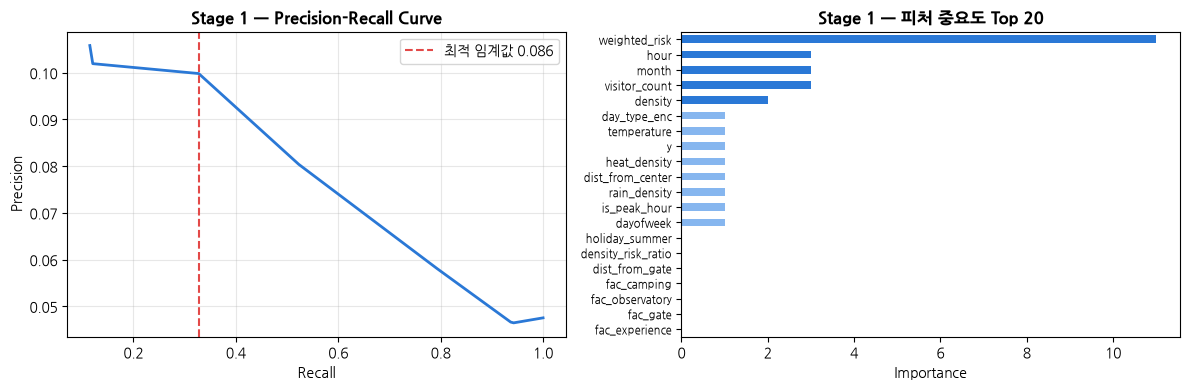

In [7]:
# Precision-Recall Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PR Curve
axes[0].plot(rec[:-1], prec[:-1], color='#2a78d6', lw=2)
axes[0].axvline(rec[opt_idx], color='#e34948', lw=1.5, ls='--', label=f'최적 임계값 {OPT_THR:.3f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Stage 1 — Precision-Recall Curve', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Feature Importance Top 20
imp = pd.Series(m1.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(20)
colors = ['#2a78d6' if i >= 15 else '#86b6ef' for i in range(len(imp))]
imp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Stage 1 — 피처 중요도 Top 20', fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('stage1_eval.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Stage 2 — 응급 유형 예측 (다중 분류)

In [8]:
# 응급 발생 레코드만 사용
emerg_tr  = train[train['emergency_occurred'] == 1]
emerg_val = val[val['emergency_occurred'] == 1]
emerg_te  = test[test['emergency_occurred'] == 1]

X2_tr,  y2_tr  = emerg_tr[FEATURE_COLS],  emerg_tr['emergency_type_enc']
X2_val, y2_val = emerg_val[FEATURE_COLS], emerg_val['emergency_type_enc']
X2_te,  y2_te  = emerg_te[FEATURE_COLS],  emerg_te['emergency_type_enc']

print(f"학습 데이터: {len(X2_tr)}건  유형 수: {y2_tr.nunique()}종")

if HAS_LGB:
    m2 = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        class_weight='balanced', random_state=42, verbose=-1,
    )
else:
    m2 = RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42,
    )
m2.fit(X2_tr, y2_tr)

acc2_val = float((m2.predict(X2_val) == y2_val).mean())
acc2_te  = float((m2.predict(X2_te)  == y2_te).mean())
f1_2_te  = f1_score(y2_te, m2.predict(X2_te), average='macro')
print(f"Val  Accuracy : {acc2_val:.4f}")
print(f"Test Accuracy : {acc2_te:.4f}  Macro-F1: {f1_2_te:.4f}")

학습 데이터: 581건  유형 수: 12종


Val  Accuracy : 0.2356
Test Accuracy : 0.3086  Macro-F1: 0.2940


## 4. Stage 3 — 중증도 예측 (순서형 분류)

In [9]:
X3_tr,  y3_tr  = emerg_tr[FEATURE_COLS],  emerg_tr['severity_enc']
X3_val, y3_val = emerg_val[FEATURE_COLS], emerg_val['severity_enc']
X3_te,  y3_te  = emerg_te[FEATURE_COLS],  emerg_te['severity_enc']

print(f"학습 데이터: {len(X3_tr)}건")
print(f"중증도 분포: {dict(y3_tr.value_counts().sort_index())}  (1=경증, 2=중등증, 3=중증)")

if HAS_LGB:
    m3 = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        class_weight='balanced', random_state=42, verbose=-1,
    )
else:
    m3 = RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42,
    )
m3.fit(X3_tr, y3_tr)

acc3_val = float((m3.predict(X3_val) == y3_val).mean())
acc3_te  = float((m3.predict(X3_te)  == y3_te).mean())
f1_3_te  = f1_score(y3_te, m3.predict(X3_te), average='macro')
print(f"Val  Accuracy : {acc3_val:.4f}")
print(f"Test Accuracy : {acc3_te:.4f}  Macro-F1: {f1_3_te:.4f}")

M3_CLASSES = list(m3.classes_)
print(f"m3 클래스: {M3_CLASSES}")

학습 데이터: 581건
중증도 분포: {1: np.int64(351), 2: np.int64(170), 3: np.int64(60)}  (1=경증, 2=중등증, 3=중증)


Val  Accuracy : 0.4195
Test Accuracy : 0.5062  Macro-F1: 0.3486
m3 클래스: [np.int64(1), np.int64(2), np.int64(3)]


## 5. 위험도 스코어 시스템

In [10]:
SEV_WEIGHTS = np.array([0.0, 1.0, 2.5, 5.0])   # none / 경증 / 중등증 / 중증

def compute_risk_scores(X_df):
    # 배치 위험도 스코어 계산 (Stage 1+3 결합)
    p_emerg  = m1.predict_proba(X_df)[:, 1]
    p_s_raw  = m3.predict_proba(X_df)            # shape (n, len(M3_CLASSES))

    p_sev = np.zeros((len(X_df), 4))
    for j, cls in enumerate(M3_CLASSES):
        p_sev[:, int(cls)] = p_s_raw[:, j]

    exp_sev    = p_sev @ SEV_WEIGHTS              # expected severity
    risk_scores = np.clip(p_emerg * (1.0 + exp_sev / 5.0), 0.0, 1.0)
    return risk_scores, p_emerg, p_sev

def risk_level(score):
    if score >= 0.15:   return '위험', '#e34948'
    elif score >= 0.07: return '주의', '#eda100'
    elif score >= 0.03: return '관찰', '#2a78d6'
    else:               return '안전', '#1baf7a'

# 테스트셋 전체 스코어 계산
rs_te, p1_te_arr, p_sev_te = compute_risk_scores(X_te)
test_scored = test.copy()
test_scored['risk_score'] = rs_te
test_scored['p_emerg']    = p1_te_arr
test_scored['risk_level'] = [risk_level(s)[0] for s in rs_te]

print("위험도 단계 분포 (테스트셋):")
print(test_scored['risk_level'].value_counts().to_string())

위험도 단계 분포 (테스트셋):
risk_level
주의    1690
관찰     121
위험      49


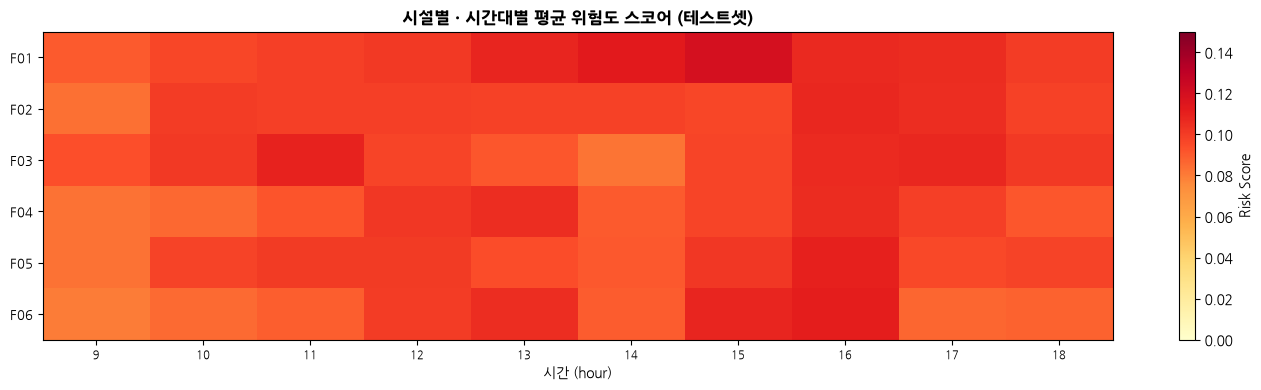

In [11]:
# 시설별 · 시간대별 평균 위험도 히트맵
pivot_risk = (test_scored
              .groupby(['facility_id', 'hour'])['risk_score']
              .mean()
              .unstack('hour'))

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot_risk.values, aspect='auto', cmap='YlOrRd',
               vmin=0, vmax=max(0.15, float(pivot_risk.values.max())))
ax.set_xticks(range(len(pivot_risk.columns)))
ax.set_xticklabels(pivot_risk.columns, fontsize=8)
ax.set_yticks(range(len(pivot_risk.index)))
ax.set_yticklabels(pivot_risk.index, fontsize=9)
ax.set_xlabel('시간 (hour)')
ax.set_title('시설별 · 시간대별 평균 위험도 스코어 (테스트셋)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, label='Risk Score')
plt.tight_layout()
plt.savefig('risk_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. AI 시나리오 대응 매뉴얼

In [12]:
MANUAL_DB = {
    '위험': {
        'title'     : '위험 (RED) — 즉각 대응',
        'trigger'   : 'risk_score ≥ 0.15',
        'actions'   : [
            '응급 대응팀 즉시 현장 파견',
            '응급 장비 준비 (AED, 들것, 응급의약품 키트)',
            '방문객 안전구역 유도 및 해당 시설 일시 폐쇄 검토',
            '119 사전 연락 및 대기 지시',
            '관리자·시설장 즉시 보고',
        ],
        'staff'     : '대응팀장 1명 + 응급처치 요원 2명 이상',
        'escalation': 'P(중증) > 0.30 → 119 즉시 출동 요청 / 의식 불명 → 헬기 이송 검토',
        'equipment' : ['AED', '들것', '응급의약품', '무전기', '안전펜스'],
    },
    '주의': {
        'title'     : '주의 (YELLOW) — 예방적 강화',
        'trigger'   : '0.07 ≤ risk_score < 0.15',
        'actions'   : [
            '예방 순찰 30분 간격 강화',
            '응급 대응 장비 위치·작동 상태 점검',
            '고위험 방문객 (노약자·어린이·임산부) 적극 모니터링',
            '기상 변화·밀도 실시간 확인',
            '대기 인력 현장 근접 배치',
        ],
        'staff'     : '예방 모니터 1명 + 대기 요원 1명',
        'escalation': '이상 징후(쓰러짐·발열·외상) 발견 즉시 위험 단계 상향',
        'equipment' : ['구급함', '무전기', '음용수', '그늘막'],
    },
    '관찰': {
        'title'     : '관찰 (BLUE) — 표준 모니터링',
        'trigger'   : '0.03 ≤ risk_score < 0.07',
        'actions'   : [
            '일반 안전 순찰 60분 간격 유지',
            '기상특보·예보 확인',
            '방문객 밀도 추이 모니터링',
            '비상 연락망 점검',
        ],
        'staff'     : '순찰 요원 1명',
        'escalation': '기상특보 발령 또는 밀도 > 0.6 시 주의 단계 상향',
        'equipment' : ['구급함', '무전기'],
    },
    '안전': {
        'title'     : '안전 (GREEN) — 정상 운영',
        'trigger'   : 'risk_score < 0.03',
        'actions'   : ['표준 안전 점검 루틴 수행', '시설 상태 확인'],
        'staff'     : '최소 순찰 인원',
        'escalation': '이상 없음',
        'equipment' : ['구급함'],
    },
}

WEATHER_NOTE = {
    'heatwave': '\n  [폭염] 그늘·음용수 추가 배치, 열사병 집중 모니터링, 피크타임(13·15시) 야외 자제 권고',
    'rain'    : '\n  [강우] 미끄러짐 주의 안내, 낙뢰 위험 시설 대피, 우천 장비 점검',
    'normal'  : '',
}

FAC_NOTE = {
    'fac_camping'    : '야영장 — 장기 체류자 탈수·열사병 위험',
    'fac_experience' : '체험장 — 활동 중 외상·골절 주의',
    'fac_gate'       : '관문 — 혼잡 시 낙상·압사 주의',
    'fac_observatory': '전망대 — 고소 추락·현기증 위험',
    'fac_playground' : '놀이터 — 어린이 외상·골절 빈발',
}

SEV_LABEL = {0: '해당없음', 1: '경증', 2: '중등증', 3: '중증'}

def generate_manual(row, risk_score, p_emerg, p_sev_arr):
    level, _ = risk_level(risk_score)
    m = MANUAL_DB[level]

    # 기상 조건
    if row.get('is_heatwave', 0):    wk = 'heatwave'
    elif row.get('is_rain', 0):      wk = 'rain'
    else:                            wk = 'normal'

    # 시설 유형
    fac_note = next((FAC_NOTE[f] for f in FAC_NOTE if row.get(f, 0) == 1), '')

    sev_dist = '  '.join(f"{SEV_LABEL[i]}:{p_sev_arr[i]:.1%}" for i in range(4))

    lines = [
        '=' * 62,
        f"  대응 단계  : {m['title']}",
        f"  트리거    : {m['trigger']}",
        f"  위험도    : {risk_score:.4f}   P(응급)={p_emerg:.4f}",
        f"  중증도 분포: {sev_dist}",
        '=' * 62,
        '  [즉각 조치]',
    ]
    for i, act in enumerate(m['actions'], 1):
        lines.append(f"    {i}. {act}")
    lines += [
        f"  [필요 인력]    {m['staff']}",
        f"  [장비]         {', '.join(m['equipment'])}",
        f"  [에스컬레이션] {m['escalation']}",
    ]
    if fac_note:
        lines.append(f"  [시설 특이사항] {fac_note}")
    if WEATHER_NOTE[wk]:
        lines.append(WEATHER_NOTE[wk])
    lines.append('=' * 62)
    return '\n'.join(lines)

print("대응 매뉴얼 함수 정의 완료")

대응 매뉴얼 함수 정의 완료


In [13]:
# 고위험 시나리오 Top 5 시연
top5_idx = np.argsort(rs_te)[-5:][::-1]

print('[고위험 시나리오 TOP 5 — AI 대응 매뉴얼]\n')
for rank, i in enumerate(top5_idx, 1):
    row  = test.iloc[i]
    rs   = float(rs_te[i])
    p_e  = float(p1_te_arr[i])
    p_sv = p_sev_te[i]

    print(f'\n[Rank {rank}]  날짜: {row["date"].date()}  '
          f'시간: {int(row["hour"])}시  시설: {row["facility_id"]}')
    print(generate_manual(row, rs, p_e, p_sv))

[고위험 시나리오 TOP 5 — AI 대응 매뉴얼]


[Rank 1]  날짜: 2026-07-21  시간: 13시  시설: F01
  대응 단계  : 위험 (RED) — 즉각 대응
  트리거    : risk_score ≥ 0.15
  위험도    : 0.2111   P(응급)=0.1063
  중증도 분포: 해당없음:0.0%  경증:0.7%  중등증:1.9%  중증:97.4%
  [즉각 조치]
    1. 응급 대응팀 즉시 현장 파견
    2. 응급 장비 준비 (AED, 들것, 응급의약품 키트)
    3. 방문객 안전구역 유도 및 해당 시설 일시 폐쇄 검토
    4. 119 사전 연락 및 대기 지시
    5. 관리자·시설장 즉시 보고
  [필요 인력]    대응팀장 1명 + 응급처치 요원 2명 이상
  [장비]         AED, 들것, 응급의약품, 무전기, 안전펜스
  [에스컬레이션] P(중증) > 0.30 → 119 즉시 출동 요청 / 의식 불명 → 헬기 이송 검토
  [시설 특이사항] 야영장 — 장기 체류자 탈수·열사병 위험

  [폭염] 그늘·음용수 추가 배치, 열사병 집중 모니터링, 피크타임(13·15시) 야외 자제 권고

[Rank 2]  날짜: 2026-07-21  시간: 15시  시설: F05
  대응 단계  : 위험 (RED) — 즉각 대응
  트리거    : risk_score ≥ 0.15
  위험도    : 0.2089   P(응급)=0.1063
  중증도 분포: 해당없음:0.0%  경증:2.2%  중등증:3.6%  중증:94.2%
  [즉각 조치]
    1. 응급 대응팀 즉시 현장 파견
    2. 응급 장비 준비 (AED, 들것, 응급의약품 키트)
    3. 방문객 안전구역 유도 및 해당 시설 일시 폐쇄 검토
    4. 119 사전 연락 및 대기 지시
    5. 관리자·시설장 즉시 보고
  [필요 인력]    대응팀장 1명 + 응급처치 요원 2명 이상
  [장비]         AED, 들것, 응급의약품, 무전기, 안

## 7. 자원 배치 최적화 모델

In [14]:
def allocate_resources(risk_by_fac: dict, total_units: int = 6,
                       min_per_fac: float = 0.3) -> dict:
    # 위험도 기반 시설별 인력 최적 배분
    # 최소 배치(min_per_fac) 보장 후 잔여 인력을 위험도 비례 배분
    facs   = sorted(risk_by_fac.keys())
    scores = np.array([risk_by_fac[f] for f in facs], dtype=float)
    n      = len(facs)

    base      = np.full(n, min_per_fac)
    remaining = total_units - base.sum()

    if remaining <= 0:
        alloc = (scores / (scores.sum() + 1e-9)) * total_units
    else:
        weights = scores / (scores.sum() + 1e-9)
        alloc   = base + weights * remaining

    return {f: round(float(a), 2) for f, a in zip(facs, alloc)}

print("자원 배치 함수 정의 완료")

자원 배치 함수 정의 완료


In [15]:
# 테스트셋 마지막 날 기준 24시간 시뮬레이션
last_date = test['date'].dt.normalize().max()
day_data  = test[test['date'].dt.normalize() == last_date].copy()
if len(day_data) == 0:
    day_data = test.tail(60).copy()

day_data['p_emerg'] = m1.predict_proba(day_data[FEATURE_COLS])[:, 1]
p_s_day_raw = m3.predict_proba(day_data[FEATURE_COLS])
p_s_day = np.zeros((len(day_data), 4))
for j, cls in enumerate(M3_CLASSES):
    p_s_day[:, int(cls)] = p_s_day_raw[:, j]
exp_sev_day = p_s_day @ SEV_WEIGHTS
day_data['risk_score'] = np.clip(
    day_data['p_emerg'] * (1.0 + exp_sev_day / 5.0), 0.0, 1.0
)

hours      = sorted(day_data['hour'].unique())
facilities = sorted(day_data['facility_id'].unique())

rows = []
for hour in hours:
    hd = day_data[day_data['hour'] == hour]
    risk_dict = {}
    for fid in facilities:
        fr = hd[hd['facility_id'] == fid]
        risk_dict[fid] = float(fr['risk_score'].iloc[0]) if len(fr) else 0.0

    alloc = allocate_resources(risk_dict, total_units=6, min_per_fac=0.3)
    for fid in facilities:
        rs_val = risk_dict.get(fid, 0.0)
        lvl, _ = risk_level(rs_val)
        rows.append({
            'hour'    : hour,
            'facility': fid,
            'risk'    : round(rs_val, 4),
            'level'   : lvl,
            'units'   : alloc.get(fid, 0.3),
        })

schedule = pd.DataFrame(rows)
print(f"시뮬레이션 기준일: {last_date.date()}\n")
print(schedule.to_string(index=False))

시뮬레이션 기준일: 2026-07-31

 hour facility   risk level  units
    9      F01 0.0745    주의   1.04
    9      F02 0.0775    주의   1.07
    9      F03 0.0746    주의   1.04
    9      F04 0.0758    주의   1.05
    9      F05 0.0488    관찰   0.78
    9      F06 0.0742    주의   1.03
   10      F01 0.0832    주의   1.01
   10      F02 0.0874    주의   1.05
   10      F03 0.0861    주의   1.04
   10      F04 0.0746    주의   0.94
   10      F05 0.0834    주의   1.02
   10      F06 0.0745    주의   0.94
   11      F01 0.0835    주의   0.98
   11      F02 0.0858    주의   1.00
   11      F03 0.0861    주의   1.00
   11      F04 0.0925    주의   1.06
   11      F05 0.0920    주의   1.05
   11      F06 0.0745    주의   0.91
   12      F01 0.0844    주의   0.96
   12      F02 0.0950    주의   1.04
   12      F03 0.0891    주의   0.99
   12      F04 0.0854    주의   0.96
   12      F05 0.0840    주의   0.95
   12      F06 0.1021    주의   1.09
   13      F01 0.0437    관찰   0.72
   13      F02 0.0834    주의   1.11
   13      F03 0.0414    관찰   0.

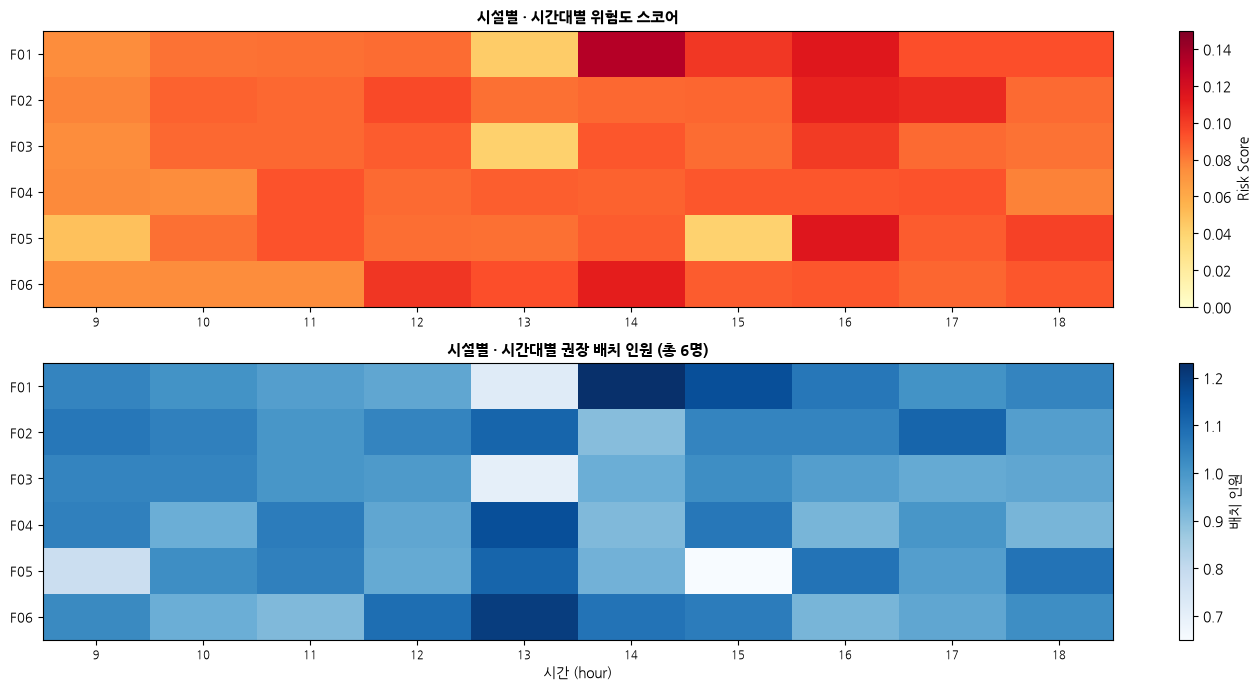

In [16]:
# 위험도 + 배치 인원 히트맵 (2행)
pivot_r = schedule.pivot(index='facility', columns='hour', values='risk')
pivot_u = schedule.pivot(index='facility', columns='hour', values='units')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

vmax_r = max(0.15, float(pivot_r.values.max()))
im1 = axes[0].imshow(pivot_r.values, aspect='auto', cmap='YlOrRd',
                      vmin=0, vmax=vmax_r)
axes[0].set_xticks(range(len(pivot_r.columns)))
axes[0].set_xticklabels(pivot_r.columns, fontsize=8)
axes[0].set_yticks(range(len(pivot_r.index)))
axes[0].set_yticklabels(pivot_r.index, fontsize=9)
axes[0].set_title('시설별 · 시간대별 위험도 스코어', fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Risk Score')

im2 = axes[1].imshow(pivot_u.values, aspect='auto', cmap='Blues')
axes[1].set_xticks(range(len(pivot_u.columns)))
axes[1].set_xticklabels(pivot_u.columns, fontsize=8)
axes[1].set_yticks(range(len(pivot_u.index)))
axes[1].set_yticklabels(pivot_u.index, fontsize=9)
axes[1].set_xlabel('시간 (hour)')
axes[1].set_title('시설별 · 시간대별 권장 배치 인원 (총 6명)', fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='배치 인원')

plt.tight_layout()
plt.savefig('resource_allocation.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
# 결과 저장
test_scored[['date', 'hour', 'facility_id', 'emergency_occurred',
             'risk_score', 'p_emerg', 'risk_level']].to_csv(
    'ecofarm_test_predictions.csv', index=False, encoding='utf-8-sig'
)
schedule.to_csv('ecofarm_resource_schedule.csv', index=False, encoding='utf-8-sig')
print("저장 완료:")
print("  ecofarm_test_predictions.csv  — 테스트셋 위험도 예측")
print("  ecofarm_resource_schedule.csv — 시설별 인력 배치 스케줄")

저장 완료:
  ecofarm_test_predictions.csv  — 테스트셋 위험도 예측
  ecofarm_resource_schedule.csv — 시설별 인력 배치 스케줄


## 8. 모델 구성 요약 및 운영 가이드

### 3단계 캐스케이드 모델
| 단계 | 타깃 | 대상 | 핵심 지표 |
|------|------|------|-----------|
| Stage 1 | emergency_occurred | 전체 레코드 | AUC · AP · F1 |
| Stage 2 | emergency_type_enc | 응급 발생만 | Accuracy · Macro-F1 |
| Stage 3 | severity_enc | 응급 발생만 | Accuracy · MAE |

### 위험도 스코어 공식
```
risk_score = P(응급) × (1 + E[중증도] / 5)   (0~1 범위)
E[중증도]  = P(경증)×1.0 + P(중등증)×2.5 + P(중증)×5.0
```

### 단계별 운영 기준
| 단계 | 스코어 | 대응 | 인력 |
|------|--------|------|------|
| 위험 (RED) | ≥ 0.15 | 즉각 대응팀 파견 | 3명+ |
| 주의 (YELLOW) | 0.07–0.15 | 예방 순찰 강화 | 2명 |
| 관찰 (BLUE) | 0.03–0.07 | 표준 모니터링 | 1명 |
| 안전 (GREEN) | < 0.03 | 정상 운영 | 최소 |

### 자원 배치 파라미터
- 총 배치 인원: **6명** (시설당 최소 0.3명 보장)
- 배분 원칙: 최소 보장 + 위험도 비례 추가 배분
- 재계산 주기: 1시간 단위 권장